# Statistical Arbitrage via PCA Eigenportfolios and Ornstein-Uhlenbeck Mean Reversion

**Hypothesis.** After a broad cross-section of US large-cap equities is projected
onto a small number of statistically-derived risk factors (via PCA on the return
correlation matrix), each stock's *residual* return -- what's left after removing
that systematic exposure -- exhibits short-horizon mean reversion. If that's true,
tracking the cumulative residual as a stochastic process and trading its deviations
from its own equilibrium should produce a market-neutral source of return.

This is the Avellaneda & Lee (2010) "Statistical Arbitrage in the U.S. Equities
Market" construction, reimplemented from scratch and tested on 2010-2026 data --
i.e. entirely out of the sample the original paper studied (pre-2008).

**The two model pieces:**
- *Factors*: PCA on the return correlation matrix -- no fundamental
  industry/style classification is assumed, the factor structure is estimated
  from returns alone. The hedge construction inside the backtest is two matrix
  products (`holdings = p - (p @ B) @ Q`).
- *Residuals*: modeled as an Ornstein-Uhlenbeck process, whose exact
  discrete-time solution is an AR(1), so mean-reversion speed, half-life, and
  equilibrium variance all come from an OLS regression. Performance is
  validated with a block bootstrap and a permutation test rather than a single
  backtest number.

**Conclusion up front:** the mean-reversion signal is real -- it beats a
turnover- and cost-matched random null by roughly 4-5 standard deviations --
but it isn't monetizable in this universe at daily frequency. The absolute
return is statistically indistinguishable from zero, the positive point
estimate is fragile across configuration variants, and the edge that existed
in 2014-2017 has decayed to roughly nothing since 2018, consistent with the
documented crowding of classical statistical arbitrage.

**Structure:** hypothesis -> data -> methodology (small runnable examples) ->
walk-forward backtest -> sub-period and robustness analysis -> statistical
validation -> failure-mode analysis. The full walk-forward backtest (820
rebalances across 16 years) is re-run via `python run_analysis.py`, and every
configuration variant discussed below via `python run_robustness.py`; this
notebook loads their cached outputs so it stays fast to read.

In [1]:
import sys
sys.path.insert(0, "..")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.data import load_returns
from src.universe import UNIVERSE
from src.factors import pca_eigenportfolios, factor_returns, residualize, standardize_returns
from src.signal import fit_ou_params, s_scores, is_tradeable, generate_positions
from src.backtest import BacktestConfig, run_backtest, performance_summary

pd.set_option("display.precision", 4)
returns = load_returns()
print(f"{returns.shape[1]} tickers, {returns.shape[0]} trading days, "
      f"{returns.index.min().date()} to {returns.index.max().date()}")

80 tickers, 4157 trading days, 2010-01-05 to 2026-07-16


## 1. Data

80 liquid large-caps spanning all 11 GICS sectors (`src/universe.py`), chosen
for continuous history back to 2010 so the sample isn't survivorship-biased
toward recent listings. Adjusted close prices from Yahoo Finance, cached
locally to parquet (`src/data.py`) so the pipeline is reproducible offline.
This is *not* the full S&P 500 -- a curated cross-section keeps the PCA
covariance matrix well-conditioned (observations >> assets in every
estimation window) and keeps iteration fast.

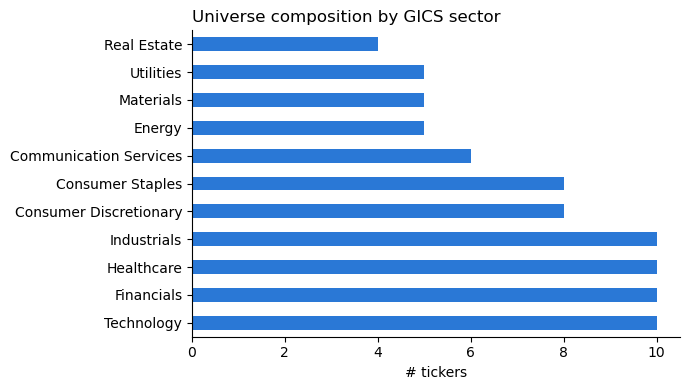

In [2]:
sector_counts = pd.Series(UNIVERSE).value_counts()
sector_counts.plot(kind="barh", color="#2a78d6", figsize=(7, 4))
plt.gca().spines[["top", "right"]].set_visible(False)
plt.title("Universe composition by GICS sector", loc="left")
plt.xlabel("# tickers")
plt.tight_layout()
plt.show()

## 2. Methodology, step by step on one window

Before running the full walk-forward loop, it's worth seeing the two model
pieces work on a single 60-trading-day window -- this is the unit of
estimation that gets repeated 820 times in the full backtest.

6 factors retained, cumulative explained variance = 56.4%


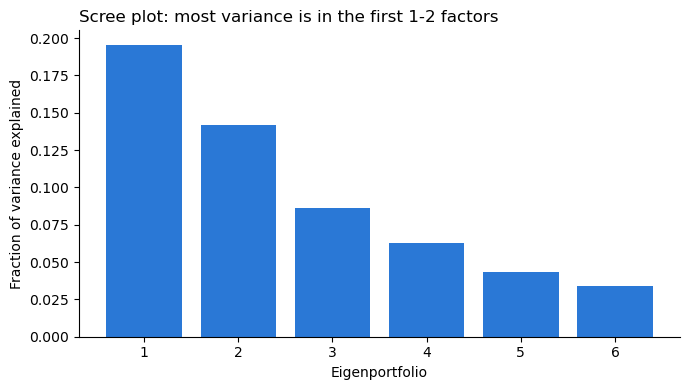

In [3]:
window = returns.iloc[-60:]
Q, explained = pca_eigenportfolios(window, var_threshold=0.55, max_factors=15)
print(f"{len(explained)} factors retained, cumulative explained variance = {explained.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(explained) + 1), explained, color="#2a78d6")
ax.set_xlabel("Eigenportfolio")
ax.set_ylabel("Fraction of variance explained")
ax.set_title("Scree plot: most variance is in the first 1-2 factors", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The first eigenportfolio is almost always market-like (every stock loads on
it with the same sign); subsequent ones pick up sector/style tilts. None of this uses industry
labels; the structure comes out of the return correlations.

Next: regress every stock's return on these factor returns, keep the residual,
and look at one stock's cumulative residual path.

       kappa       m  sigma_eq  half_life  r_squared
JPM  20.4595 -0.0063    0.0186     8.5375       0.85


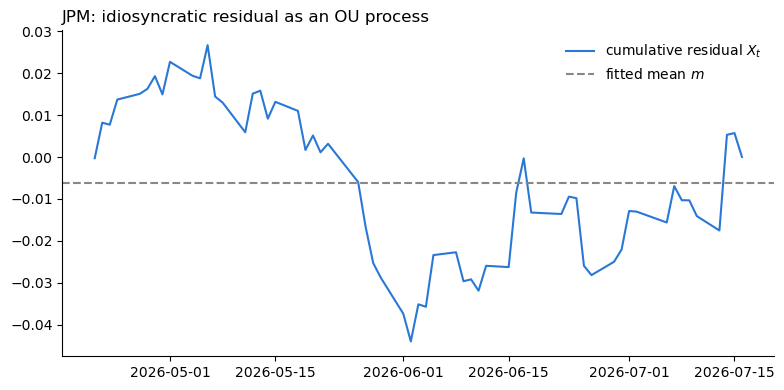

In [4]:
F = factor_returns(window, Q)
betas, resid = residualize(window, F)
cum_resid = resid.cumsum()

example = "JPM"
ou = fit_ou_params(cum_resid[[example]])
print(ou)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cum_resid.index, cum_resid[example], color="#2a78d6", label="cumulative residual $X_t$")
ax.axhline(ou.loc[example, "m"], color="#898781", linestyle="--", label="fitted mean $m$")
ax.set_title(f"{example}: idiosyncratic residual as an OU process", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`kappa` (annualized mean-reversion speed) and `half_life` come straight out of
the AR(1) coefficient: `half_life = ln(2) / kappa`. Names with a half-life longer
than 15 trading days are excluded from trading -- the OU fit on a 60-day window
can't reliably estimate reversion that slow, so acting on it would be trading
noise, not signal (`src/signal.py::is_tradeable`).

The trading rule (thresholds from Avellaneda & Lee) is a state machine on the
$s$-score $= (X_t - m)/\sigma_{eq}$: open a position when $|s| > 1.25$, close it
when $|s| < 0.5$, hold otherwise. Each stock position is **factor-hedged** --
holding stock $i$ also means shorting $\beta_{ij}$ dollars of eigenportfolio $j$
for every factor it loaded on, so the bet is genuinely on the residual, not on
smuggled-in market/sector exposure. In `src/backtest.py` the whole book is two
matrix products, `holdings = p - (p @ B) @ Q`, and `tests/test_backtest.py`
verifies the resulting book has near-zero exposure to every statistical factor.

## 3. Walk-forward backtest

Every 5 trading days, refit PCA + OU parameters on the trailing 60 days,
trade forward, and mark to market daily against realized returns. Signals are
computed from data through the close of day $t-1$ and positions earn day $t$'s
return -- the standard close-to-close execution convention -- so no parameter
is ever fit on data the strategy wouldn't have had at decision time.

One deliberate deviation from the paper: A&L estimate the PCA on a 252-day
window but the OU residuals on 60 days. This implementation defaults to 60
days for both; the paper's 252/60 split is implemented (`pca_lookback=252`)
and tested in the robustness section below -- it performs *worse* on this
2010-2026 sample.

In [5]:
with open("../results/summary.json") as f:
    summary = json.load(f)
summary["summary"]

{'annualized_return': 0.006120876759918853,
 'annualized_vol': 0.0483773039243996,
 'sharpe': 0.12652372628049088,
 'max_drawdown': -0.11794709687937666,
 'hit_rate': 0.511837930192824,
 'n_days': 4097.0}

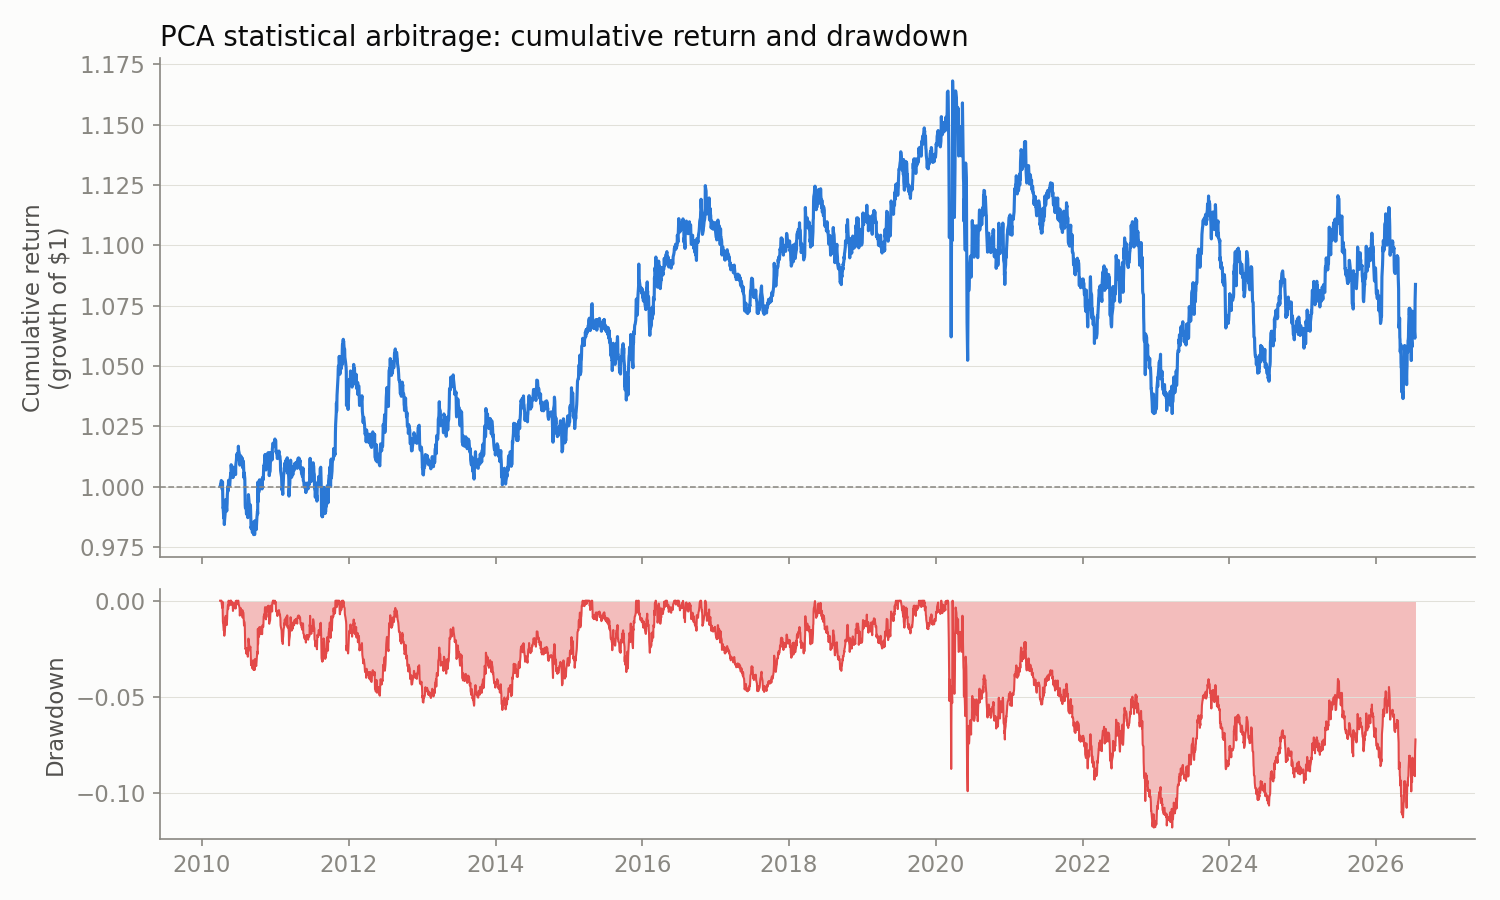

In [6]:
display(Image("../results/equity_drawdown.png"))

Full-sample Sharpe is modest (~0.13) with a max drawdown of ~12%. The
strategy's shape is not flat noise, though -- there's a clear regime.

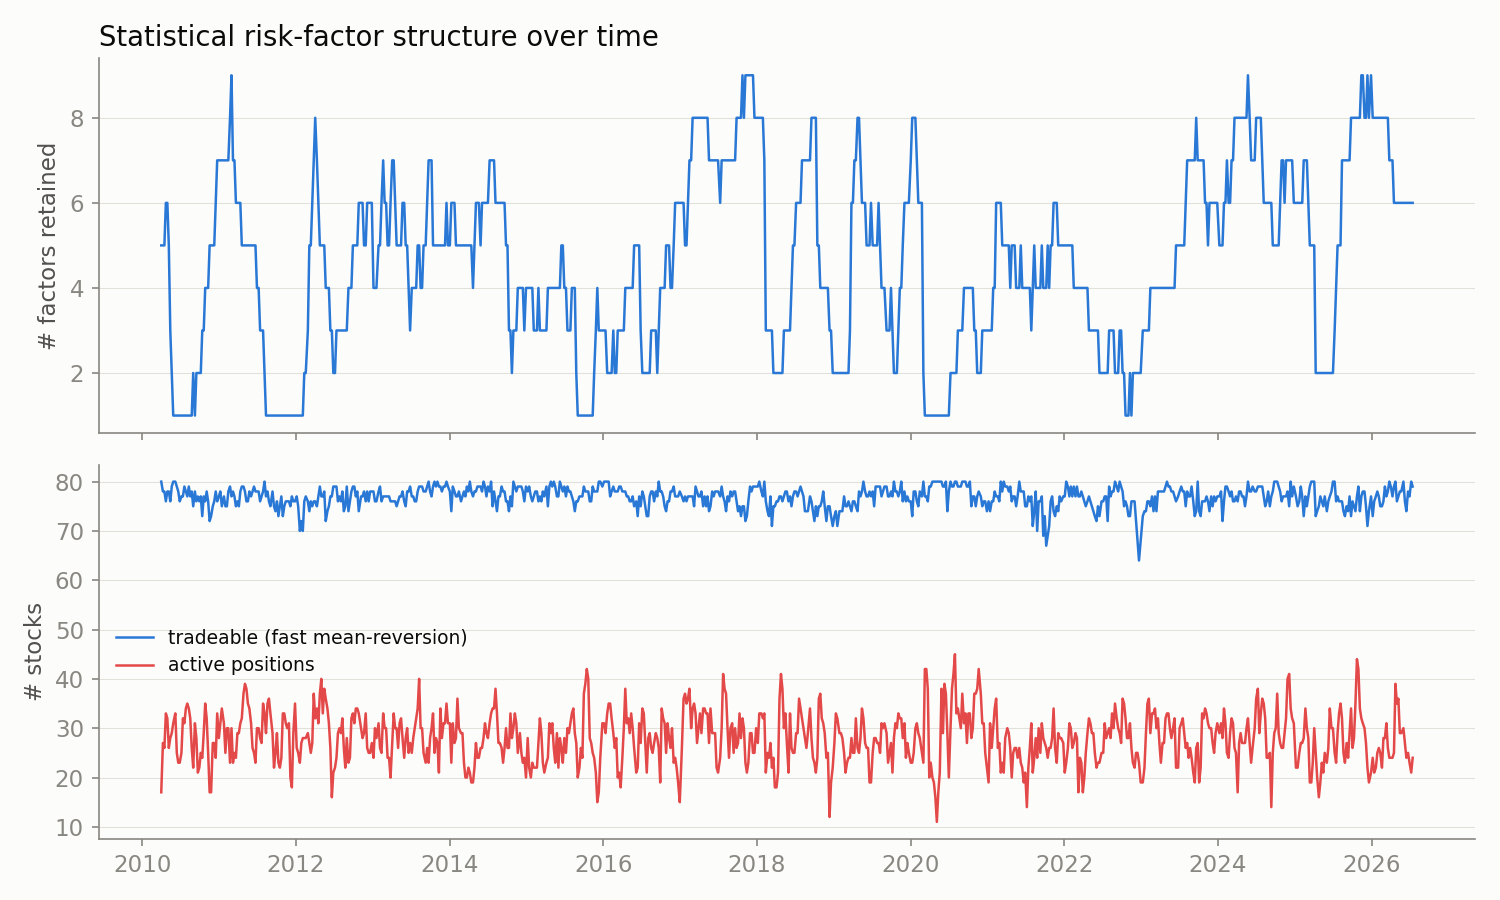

In [7]:
display(Image("../results/factor_structure.png"))

The number of statistical factors needed to explain 55% of cross-sectional
variance ranges from 1 (extreme low-dispersion periods) to 9 (regime
transitions, e.g. 2020, 2022). The number of risk dimensions changes
with the correlation regime. The number of tradeable (fast-reverting) names and active
positions tracks that instability.

## 4. Sub-period breakdown

Splitting the full sample into four multi-year windows tells a much more
specific story than the single Sharpe number above.

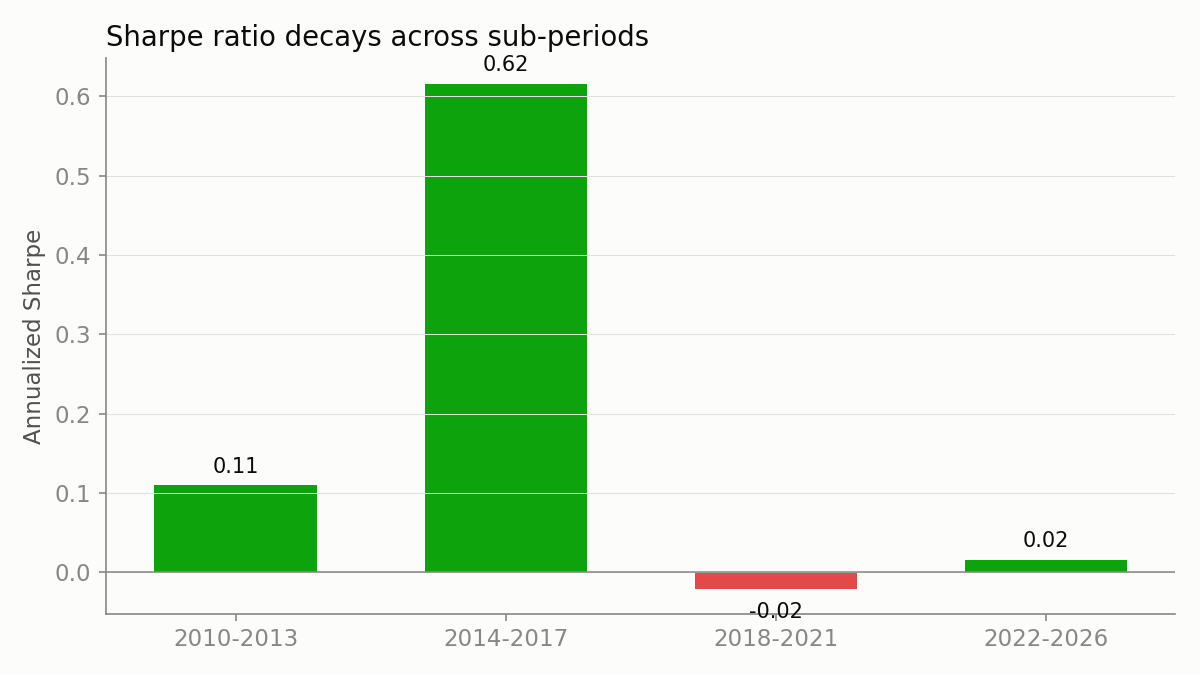

{'2010-2013': 0.11000220776588865,
 '2014-2017': 0.6162898287169144,
 '2018-2021': -0.020661377011833303,
 '2022-2026': 0.015781145416867724}

In [8]:
display(Image("../results/subperiod_sharpe.png"))
summary["subperiod_sharpes"]

**2014-2017 is where this strategy actually worked** (Sharpe 0.62). Performance
is roughly flat in 2010-2013 and from 2018 onward. This is consistent with the
well-documented decay of classical statistical arbitrage since the early 2010s:
more capital chasing the same short-horizon mean-reversion anomaly, tighter
effective spreads from electronic market-making, and lower average
cross-sectional dispersion have compressed the edge that made these strategies
profitable when Avellaneda & Lee published in 2008-2010. This backtest, run on
a period the original paper never saw, reproduces that decay directly rather
than assuming it.

## 5. Robustness: is the positive point estimate stable?

Every "X was tested" claim below is a full walk-forward rerun
(`run_robustness.py` writes `results/robustness.json`; the table renders from
that file, so the narrative can't drift from the numbers).

In [9]:
with open("../results/robustness.json") as f:
    robustness = json.load(f)
rob = pd.DataFrame(robustness).T
rob

,sharpe,annualized_return,max_drawdown,avg_turnover_per_rebalance,annualized_cost_drag
"default (60d window, weekly refit, 55% var threshold)",0.127,0.0061,-0.118,0.846,0.0213
daily refit (paper's cadence),-0.226,-0.0115,-0.243,0.390,0.0491
fixed 5 factors (no variance threshold),-0.105,-0.0044,-0.174,0.845,0.0213
A&L window split (252d PCA / 60d OU),-0.151,-0.0072,-0.201,0.885,0.0223
variance threshold 45%,0.148,0.0078,-0.107,0.814,0.0205
variance threshold 65%,-0.016,-0.0007,-0.188,0.909,0.0229


**The sign of the full-sample Sharpe is configuration-dependent.** Across six reasonable variants it spans roughly
-0.23 to +0.15:

- **Daily refitting** (the paper's cadence) more than doubles annualized
  transaction-cost drag (~2.1% -> ~4.9%) and flips the Sharpe firmly negative.
  The extra estimation frequency doesn't recover enough signal to pay for
  itself.
- **A fixed 5-factor model** (instead of the adaptive 55%-of-variance rule)
  flips negative -- the adaptive factor count is load-bearing, not a cosmetic
  choice.
- **The paper's own 252/60 window split** underperforms the single 60-day
  window on this sample.
- **The variance threshold matters more than it should**: 45% slightly
  improves on the default (+0.15 vs +0.13) while 65% erases the edge entirely
  (-0.02). A 20-point change in one hyperparameter swings the Sharpe by the
  full size of the claimed effect.

A point estimate this sensitive is exactly the situation where a single
backtest Sharpe should not be trusted -- which is what the next section is
for. (All parameters were fixed a priori from the paper -- thresholds
1.25/0.5, the 55% variance rule, 60-day window -- not tuned on this sample.
The table is a sensitivity check, not a menu: picking the best row after the
fact would be exactly the overfitting it's meant to expose.)

## 6. Statistical validation

A single Sharpe ratio is a point estimate with no error bar. Two checks, for
two different questions.

**(a) Is the absolute return distinguishable from zero?** Block bootstrap
(block size 20 days, to respect the autocorrelation from multi-day holding
periods) on the realized daily-return series.

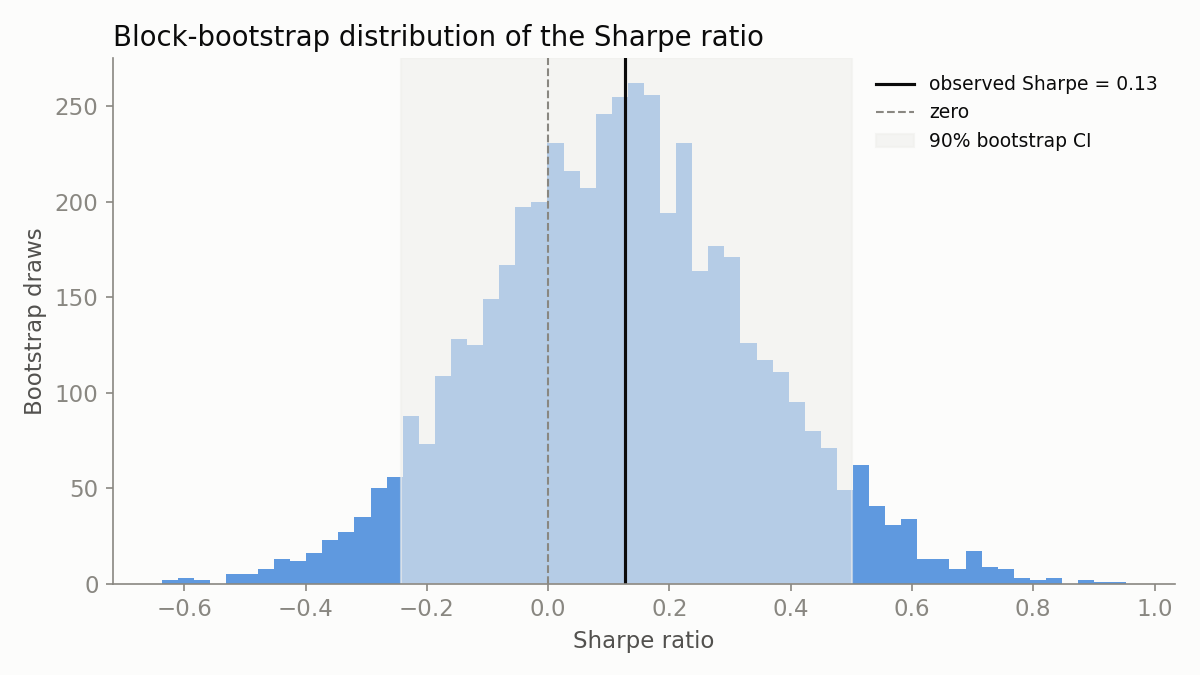

90% CI on Sharpe: [-0.24189958973235867, 0.5014129750835327]
P(mean daily return <= 0): 0.301


In [10]:
display(Image("../results/bootstrap_sharpe.png"))
print(f"90% CI on Sharpe: {summary['bootstrap_sharpe_ci90']}")
print(f"P(mean daily return <= 0): {summary['bootstrap_p_value_mean_leq_0']:.3f}")

Answer: **no, not confidently.** The 90% CI comfortably straddles zero, and
there's a ~30% chance under the bootstrap that the true mean return is
non-positive -- corroborating what the robustness table already suggested.
Taken alone, this looks like a strategy indistinguishable from noise.

**(b) Is the *signal* doing anything a random assignment wouldn't?** This is a
different, arguably more important question, and it's answered by literally
rerunning the entire walk-forward backtest 20 times, at each rebalance randomly
reassigning which tradeable stock's OU $s$-score gets acted on -- same hedge
construction, same turnover, same costs; only the specific stock-to-signal
mapping is destroyed.

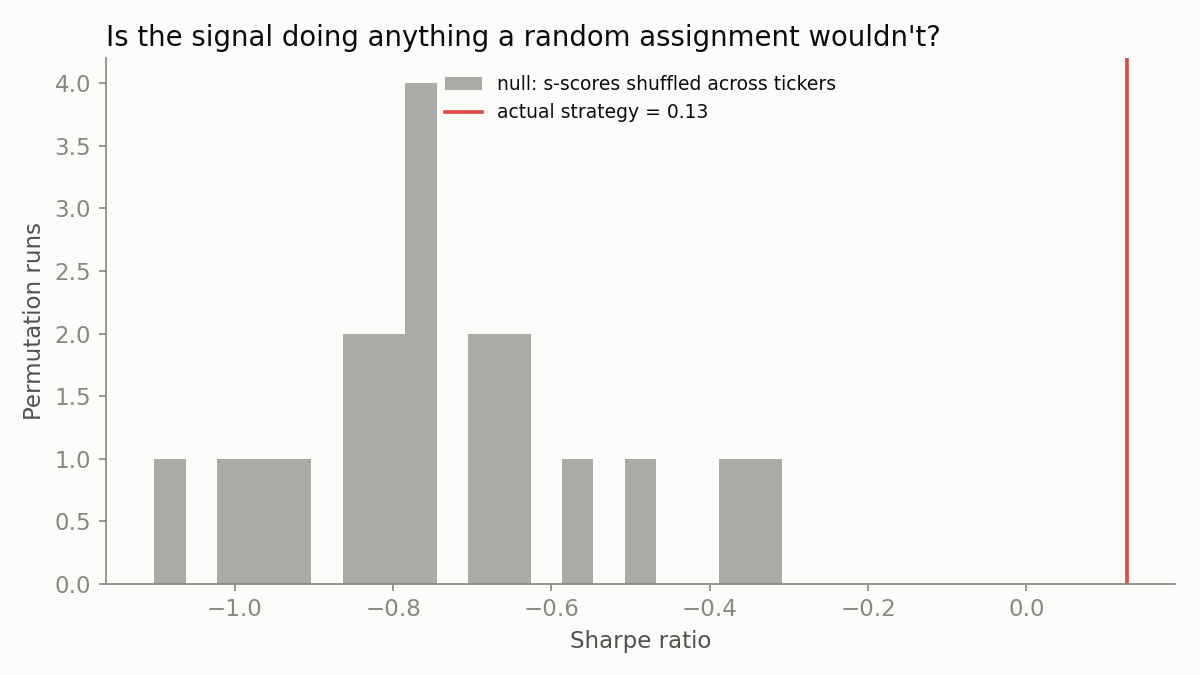

Real Sharpe: 0.127
Null (shuffled signal) mean/std: -0.734 / 0.195
Empirical p-value: 0.000


In [11]:
display(Image("../results/permutation_null.png"))
print(f"Real Sharpe: {summary['permutation_real_sharpe']:.3f}")
print(f"Null (shuffled signal) mean/std: {summary['permutation_null_mean']:.3f} / {summary['permutation_null_std']:.3f}")
print(f"Empirical p-value: {summary['permutation_p_value']:.3f}")

Answer: **yes, decisively.** A random market-neutral book with identical
turnover and cost structure loses money on average (null mean Sharpe of about
-0.73) -- transaction costs alone are a real drag once you're rebalancing ~28
factor-hedged positions every week. The actual signal clears that null by
roughly 4-5 standard deviations.

Put together: **the mean-reversion effect this strategy is built to exploit
is real and detectable, but after realistic transaction costs, on this
universe, post-2018, it is too small to produce an absolute return
distinguishable from zero.** The configuration sensitivity in section 5 is
what that marginality looks like up close.

## 7. Failure-mode analysis and limitations

- **Regime dependence.** The edge is concentrated in 2014-2017; 2010-2013 and
  2018-2026 are close to flat. A production version would need a regime filter
  (e.g. trade size scaled by recent cross-sectional dispersion) rather than a
  constant-size book through every period.
- **Transaction costs dominate at this turnover.** Average turnover per weekly
  rebalance is ~85% of gross exposure; at 5bps one-way that's ~2.1% of
  annualized drag against a gross edge of roughly 2.7% -- the strategy spends
  most of what it makes on trading. This is why the daily-refit variant fails:
  drag rises to ~4.9% for no compensating signal.
- **Configuration fragility.** Section 5: the sign of the full-sample Sharpe
  is not stable across reasonable variants (factor-count rule, window split,
  variance threshold). The permutation result is the robust finding; the point
  estimate is not.
- **No market-impact or slippage model.** Costs are a flat 5bps of traded
  notional; real execution of a ~28-name, weekly-turnover book would face
  wider effective spreads on the less liquid names in the universe.
- **Universe is 80 large-caps, not the full cross-section.** The original
  paper traded over a thousand names (US stocks above ~$1B market cap);
  concentration in a smaller, more efficiently-priced universe plausibly
  understates how much edge exists in the broader, less-covered part of the
  market.
- **Daily marking without intra-period compounding.** Holdings are held at
  fixed dollar weights between rebalances -- fine for evaluating the signal,
  but P&L numbers would need proper position accounting before being treated
  as investable.

**What I'd try next:** a dispersion-conditioned regime filter (only deploy when
recent cross-sectional dispersion is high); an intraday version of the same
idea, where mean-reversion half-lives are shorter and less crowded than daily;
a broader and less liquid universe where the anomaly is less arbitraged; and
replacing the linear OU fit with a nonlinear residual-return forecast to see
whether the *direction* of the effect survives where the *linear* AR(1) edge
doesn't.